# Modeling Histórico Chat

---

## Objetivo

O objetivo desse notebook é realizar análises exploratórias das features criadas até aqui e suas interações entre si, técnicas de Machine Learning para modelar linear e não linearmente a predição final, junto com benchmarks de modelos e resultado final.

---

## Código

---

### EDA

In [1]:
import pandas as pd

df_train = pd.read_parquet("../../dados/processed/train.parquet")
df_test = pd.read_parquet("../../dados/processed/test.parquet")

print("Primeiras linhas dados de treino")
print(df_train.head())
print("=" * 50)
print("Primeiras linhas dados de teste")
print(df_test.head())

Primeiras linhas dados de treino
                                            mensagem  log_duracao  \
0  irmão me fala o que a inglaterra vai arrumar c...     1.352393   
1  se preparem para dormir aqui pode po pera no s...     7.083835   
2  desgraça kkkkkkkkkkkkk perdigueiro dinâmico al...     6.692104   
3  é aqui no es eu ja sou explorado porra pelo me...     0.725937   
4  nada a ver <gif > @jão o radmin tá minerando b...     2.656757   

  dia_semana_inicio dia_semana_fim  hora_inicio  hora_fim  qtd_caracteres  \
0       Terça-feira    Terça-feira           17        18              93   
1            Sábado        Domingo           14        10              87   
2      Quinta-feira    Sexta-feira           22        11              77   
3      Quinta-feira   Quinta-feira           14        14              94   
4      Quarta-feira   Quarta-feira           20        21             146   

   qtd_palavras  caracter_por_palavra   membro  
0            19              4.894737  L

In [2]:
import numpy as np

cluster_train_15k = np.load("../../artifacts/clustering/clusters_train_15.npy")
cluster_test_15k = np.load("../../artifacts/clustering/clusters_test_15.npy")

In [3]:
df_train["cluster_15"] = cluster_train_15k
df_test["cluster_15"]= cluster_test_15k

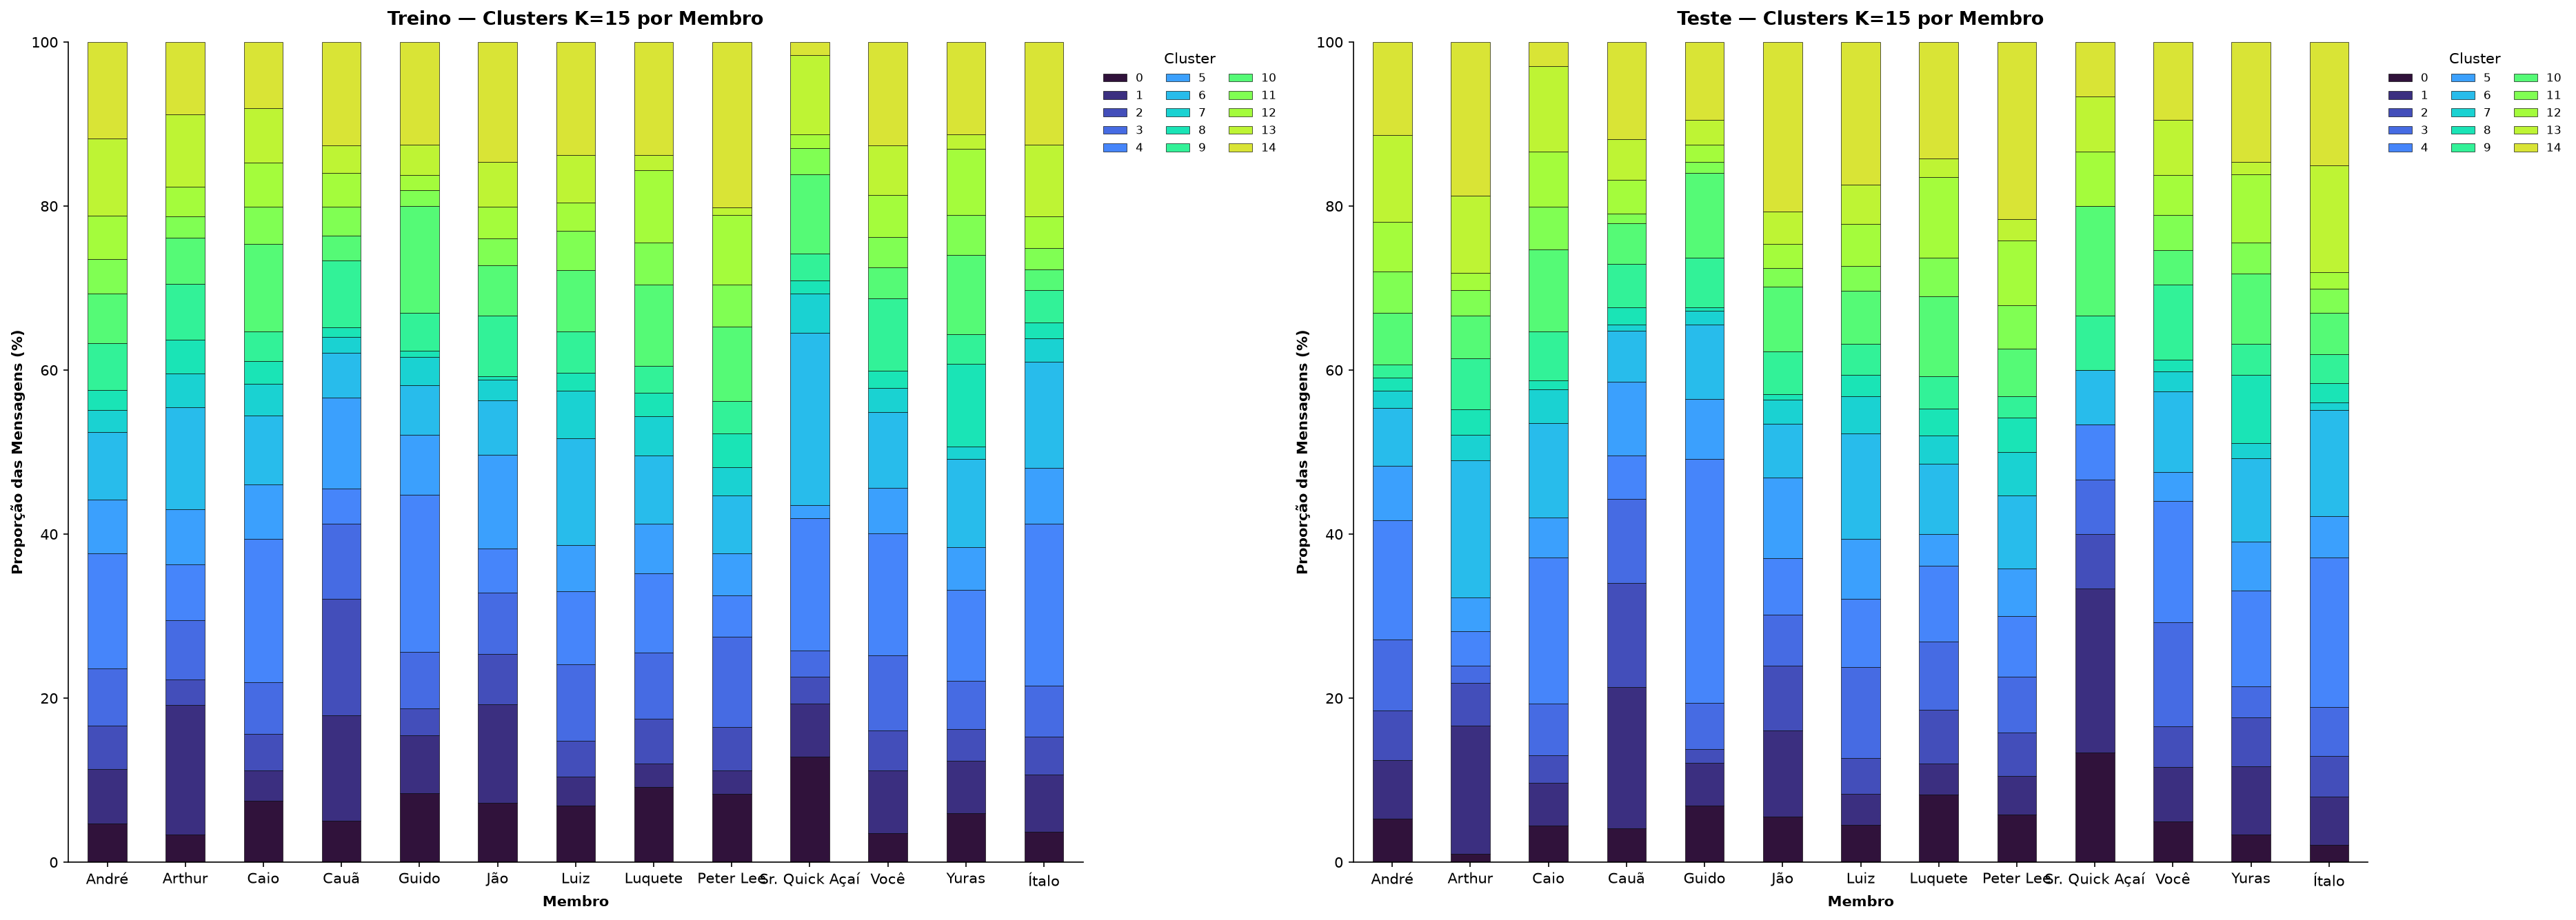

In [4]:
import matplotlib.pyplot as plt
def get_cluster_member_prop(df, cluster_col):
    ct = pd.crosstab(df["membro"], df[cluster_col], normalize="index") * 100
    return ct


fig, axes = plt.subplots(1, 2, figsize=(25, 9), dpi=150)

configs = [
    (df_train, "cluster_15", axes[0], "Treino — Clusters K=15 por Membro"),
    (df_test, "cluster_15", axes[1], "Teste — Clusters K=15 por Membro"),
]

cmap_20 = plt.get_cmap("tab20", 20)
cmap_25 = plt.get_cmap("turbo", 25)

for df, col, ax, title in configs:
    prop_df = get_cluster_member_prop(df, col)

    k_num = int(col.split("_")[1])
    colors = (
        cmap_20(np.linspace(0, 1, 20))
        if k_num == 20
        else cmap_25(np.linspace(0, 1, 25))
    )

    prop_df.plot(
        kind="bar", stacked=True, ax=ax, color=colors, edgecolor="black", linewidth=0.3
    )

    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Membro", fontsize=10, fontweight="bold")
    ax.set_ylabel("Proporção das Mensagens (%)", fontsize=10, fontweight="bold")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

    ncols = 2 if k_num == 20 else 3
    ax.legend(
        title="Cluster",
        bbox_to_anchor=(1.01, 1),
        loc="upper left",
        fontsize=8,
        ncol=ncols,
        frameon=False,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

pt_stopwords = stopwords.words('portuguese')

def extrair_top_termos_clusters(df, text_col, cluster_col, top_n=10):
    """
    Calcula as palavras mais representativas de cada cluster usando c-TF-IDF simplificado.
    """
    df_grouped = df.groupby(cluster_col)[text_col].apply(lambda texts: " ".join(texts.astype(str))).reset_index()
    
    vectorizer = TfidfVectorizer(
        max_df=0.7,         
        min_df=2,         
        stop_words=pt_stopwords,
        ngram_range=(1, 2)   
    )
    
    tfidf_matrix = vectorizer.fit_transform(df_grouped[text_col])
    feature_names = vectorizer.get_feature_names_out()
    
    top_terms_per_cluster = {}
    for idx, row in df_grouped.iterrows():
        cluster_id = row[cluster_col]
        scores = tfidf_matrix[idx].toarray().flatten()
        top_indices = scores.argsort()[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_terms_per_cluster[cluster_id] = top_words
        
    return pd.DataFrame(top_terms_per_cluster).T

def print_resumo_clusters(df_top_terms, nome_k):
    print(f"\n==================== RESUMO SEMÂNTICO ({nome_k}) ====================")
    for cluster_id, row in df_top_terms.iterrows():
        palavras = ", ".join(row.values)
        print(f"Cluster {cluster_id:2d} -> [{palavras}]")

top_k15 = extrair_top_termos_clusters(df_train, "mensagem", "cluster_15", top_n=8)

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/kau/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):


In [6]:
print_resumo_clusters(top_k15, "K=15")


==================== RESUMO SEMÂNTICO (K=15) ====================
Cluster  0 -> [ver filme, instantes aguardando, filmes, 2027, tropa vai, diretor, instantes luquete, netflix]
Cluster  1 -> [ferramenta, encaminhada encaminhada, rpe, reclamômetro luiz, resolve, dor, luiz lucas, reclamômetro]
Cluster  2 -> [argentina, marrocos, paraguai, portugal, vencedor, inglaterra, haiti, 06]
Cluster  3 -> [racista, jesus, jesus cristo, homem aranha, aranha, arthur vai, racismo, cristo]
Cluster  4 -> [kkkkkkkkk, kkkkkkkkkkkkkkkkk, kkkkkkkkkkkkkk, kkkkkkkkkkkkkkkk, kkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkkk, kkkkkkkkkkkkkkkkkkk, kkkkkkkkkkkkkkkkkkkkkk, kkkkkkkkkkkkkkkkkkkkkkkkkk]
Cluster  5 -> [gols, jogadores, jogador, ver jogo, jogou, minecraft, todos jogos, gamepass]
Cluster  6 -> [server, meta ai, bora bora, jão kau, feliz aniversário, andré ana, net, kau luiz]
Cluster  7 -> [lucas gay, pegar mulher, homossexual, tá seguindo, namorar, namorado, ti, gabi]
Cluster  8 -> [votar, político, votação,

In [7]:
print(df_train[df_train["cluster_15"] == 13][
    ["membro", "mensagem"]
].sample(20, random_state=42))

       membro                                           mensagem
8822    André  to pegando ym comes tb qnd tiverem no lobby me...
14359  Arthur  menos militante kkkkkkkkkkkkkkk < > sdds do pe...
6964     Caio  < > to confiante kkkkkkkkkkkkkkkkkkkkkkkkkkkkk...
15583   André  kkkkkkkkkkkkkkkkkkkkkkkkkk removeu você (\__/)...
7478      Jão  < > caozeiro do krl manda print da dm kaksksow...
11119    Caio  pode não desculpa é perigoso kkkkkkkkkkkkkk kk...
14946    Caio  < > kkkkkkkkkkkk adeus 3° camisa 😢 mas aí perd...
4629      Jão    krl golaço deles agr pqp kkkkkkakakakakakak pqp
2585    Ítalo  arthur aparencia? pq pergunta mano kkkkkkkkkkk...
10748     Jão  sigo ele e esqueci o nome < de > jsksksksksks ...
15748   André  congelado linda kkkkkkkkkkkkkkkkkkkkkkkkkkkkkk...
1703    Yuras  aql q joguei é luz e som ela faz um barulhao d...
3389     Caio  reclamômetro: luiz: 2 lucas: 2 explicação: lui...
2396    Ítalo  ou começam a valorizar ele kkkkkkkkkkkkkkkkkkk...
12492   André      < > kk

In [8]:
from sklearn.feature_selection import mutual_info_classif

features_mi = [
    "log_duracao",
    "hora_inicio",
    "hora_fim",
    "qtd_caracteres",
    "qtd_palavras",
    "caracter_por_palavra",
    "cluster_15"
]

# Calcula a Informação Mútua de cada feature em relação ao alvo ("membro")
mi_values = mutual_info_classif(
    df_train[features_mi], 
    df_train["membro"], 
    discrete_features=[features_mi.index("cluster_15")], # Indica que cluster_15 é categórica/discreta
    random_state=42
)

# Organiza em uma Series para fácil leitura
mi_series = pd.Series(mi_values, index=features_mi).sort_values(ascending=False)

print("Informação Mútua por Feature:")
print(mi_series)

Informação Mútua por Feature:
log_duracao             0.090088
qtd_caracteres          0.068734
cluster_15              0.068680
qtd_palavras            0.065196
caracter_por_palavra    0.063685
hora_fim                0.061466
hora_inicio             0.060510
dtype: float64


In [9]:
from scipy import sparse 

embedding_train = np.load("../../artifacts/embedding/embeddings_train.npy")
embedding_test = np.load("../../artifacts/embedding/embeddings_test.npy")

tfidf_train = sparse.load_npz("../../artifacts/tfidf/tfidf_train.npz")
tfidf_test = sparse.load_npz("../../artifacts/tfidf/tfidf_test.npz")

In [10]:
print(f"Número de linhas dataset treino: {df_train.shape[0]}")
print("=" * 50)
print(f"Número de linhas embeddings treino: {embedding_train.shape[0]}")
print("=" * 50)
print(f"Número de linhas TF-IDF treino: {tfidf_train.shape[0]}")
print("=" * 50 + "\n" * 3)

print(f"Número de linhas dataset teste: {df_test.shape[0]}")
print("=" * 50)
print(f"Número de linhas embeddings teste: {embedding_test.shape[0]}")
print("=" * 50)
print(f"Número de linhas TF-IDF teste: {tfidf_test.shape[0]}")
print("=" * 50 + "\n")

Número de linhas dataset treino: 15796
Número de linhas embeddings treino: 15796
Número de linhas TF-IDF treino: 15796



Número de linhas dataset teste: 3949
Número de linhas embeddings teste: 3949
Número de linhas TF-IDF teste: 3949



### Feature Engineering

In [11]:
# =========================
# TREINO
# =========================

df_train["hora_inicio_sin"] = np.sin(
    2 * np.pi * df_train["hora_inicio"] / 24
)

df_train["hora_inicio_cos"] = np.cos(
    2 * np.pi * df_train["hora_inicio"] / 24
)

df_train["hora_fim_sin"] = np.sin(
    2 * np.pi * df_train["hora_fim"] / 24
)

df_train["hora_fim_cos"] = np.cos(
    2 * np.pi * df_train["hora_fim"] / 24
)

hora_inicio_sin_train = df_train["hora_inicio_sin"].values.reshape(-1, 1)
hora_inicio_cos_train = df_train["hora_inicio_cos"].values.reshape(-1, 1)

hora_fim_sin_train = df_train["hora_fim_sin"].values.reshape(-1, 1)
hora_fim_cos_train = df_train["hora_fim_cos"].values.reshape(-1, 1)

log_duracao_train = df_train["log_duracao"].values.reshape(-1, 1)

df_dia_inicio_dummies_train = pd.get_dummies(
    df_train["dia_semana_inicio"],
    prefix="dia_inicio",
    drop_first=True,
    dtype=float
)

df_dia_fim_dummies_train = pd.get_dummies(
    df_train["dia_semana_fim"],
    prefix="dia_fim",
    drop_first=True,
    dtype=float
)

dia_inicio_dummies_array_train = df_dia_inicio_dummies_train.to_numpy()
dia_fim_dummies_array_train = df_dia_fim_dummies_train.to_numpy()

qtd_palavras_train = df_train["qtd_palavras"].values.reshape(-1, 1)
qtd_caracteres_train = df_train["qtd_caracteres"].values.reshape(-1, 1)
caracter_por_palavra_train = df_train["caracter_por_palavra"].values.reshape(-1, 1)


df_cluster15_dummies_train = pd.get_dummies(
    df_train["cluster_15"],
    prefix="cluster_15",
    drop_first=True,
    dtype=float
)

cluster15_dummies_array_train = df_cluster15_dummies_train.to_numpy()


# =========================
# TESTE
# =========================

df_test["hora_inicio_sin"] = np.sin(
    2 * np.pi * df_test["hora_inicio"] / 24
)

df_test["hora_inicio_cos"] = np.cos(
    2 * np.pi * df_test["hora_inicio"] / 24
)

df_test["hora_fim_sin"] = np.sin(
    2 * np.pi * df_test["hora_fim"] / 24
)

df_test["hora_fim_cos"] = np.cos(
    2 * np.pi * df_test["hora_fim"] / 24
)

hora_inicio_sin_test = df_test["hora_inicio_sin"].values.reshape(-1, 1)
hora_inicio_cos_test = df_test["hora_inicio_cos"].values.reshape(-1, 1)

hora_fim_sin_test = df_test["hora_fim_sin"].values.reshape(-1, 1)
hora_fim_cos_test = df_test["hora_fim_cos"].values.reshape(-1, 1)

log_duracao_test = df_test["log_duracao"].values.reshape(-1, 1)

df_dia_inicio_dummies_test = pd.get_dummies(
    df_test["dia_semana_inicio"],
    prefix="dia_inicio",
    drop_first=True,
    dtype=float
)

df_dia_inicio_dummies_test = df_dia_inicio_dummies_test.reindex(
    columns=df_dia_inicio_dummies_train.columns,
    fill_value=0
)

df_dia_fim_dummies_test = pd.get_dummies(
    df_test["dia_semana_fim"],
    prefix="dia_fim",
    drop_first=True,
    dtype=float
)

df_dia_fim_dummies_test = df_dia_fim_dummies_test.reindex(
    columns=df_dia_fim_dummies_train.columns,
    fill_value=0
)

dia_inicio_dummies_array_test = df_dia_inicio_dummies_test.to_numpy()
dia_fim_dummies_array_test = df_dia_fim_dummies_test.to_numpy()

qtd_palavras_test = df_test["qtd_palavras"].values.reshape(-1, 1)
qtd_caracteres_test = df_test["qtd_caracteres"].values.reshape(-1, 1)
caracter_por_palavra_test = df_test["caracter_por_palavra"].values.reshape(-1, 1)

df_cluster15_dummies_test = pd.get_dummies(
    df_test["cluster_15"],
    prefix="cluster_15",
    drop_first=True,
    dtype=float
)

df_cluster15_dummies_test = df_cluster15_dummies_test.reindex(
    columns=df_cluster15_dummies_train.columns,
    fill_value=0
)

cluster15_dummies_array_test = df_cluster15_dummies_test.to_numpy()

In [12]:
import scipy.sparse as sp

X_train = sp.hstack([
    hora_inicio_sin_train,
    hora_inicio_cos_train,
    hora_fim_sin_train,
    hora_fim_cos_train,
    log_duracao_train,
    dia_inicio_dummies_array_train,
    dia_fim_dummies_array_train,
    qtd_palavras_train,
    qtd_caracteres_train,
    caracter_por_palavra_train,
    cluster15_dummies_array_train,
    embedding_train,
    tfidf_train
]).tocsr()

X_test = sp.hstack([
    hora_inicio_sin_test,
    hora_inicio_cos_test,
    hora_fim_sin_test,
    hora_fim_cos_test,
    log_duracao_test,
    dia_inicio_dummies_array_test,
    dia_fim_dummies_array_test,
    qtd_palavras_test,
    qtd_caracteres_test,
    caracter_por_palavra_test,
    cluster15_dummies_array_test,
    embedding_test,
    tfidf_test
]).tocsr()

y_train = df_train["membro"]
y_test = df_test["membro"]

/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1435: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/kau/Documentos/SCIA/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


==============================REPORT==============================
                precision    recall  f1-score   support

         André       0.20      0.06      0.09       379
        Arthur       0.08      0.17      0.10        96
          Caio       0.24      0.24      0.24       269
          Cauã       0.24      0.35      0.28       244
         Guido       0.23      0.30      0.26       232
           Jão       0.27      0.18      0.21       305
          Luiz       0.30      0.13      0.18       505
       Luquete       0.44      0.20      0.28       825
     Peter Lee       0.12      0.27      0.16       190
Sr. Quick Açaí       0.01      0.20      0.02        15
          Você       0.18      0.26      0.21       284
         Yuras       0.18      0.16      0.17       266
         Ítalo       0.23      0.31      0.26       339

      accuracy                           0.21      3949
     macro avg       0.21      0.22      0.19      3949
  weighted avg       0.27      0.21

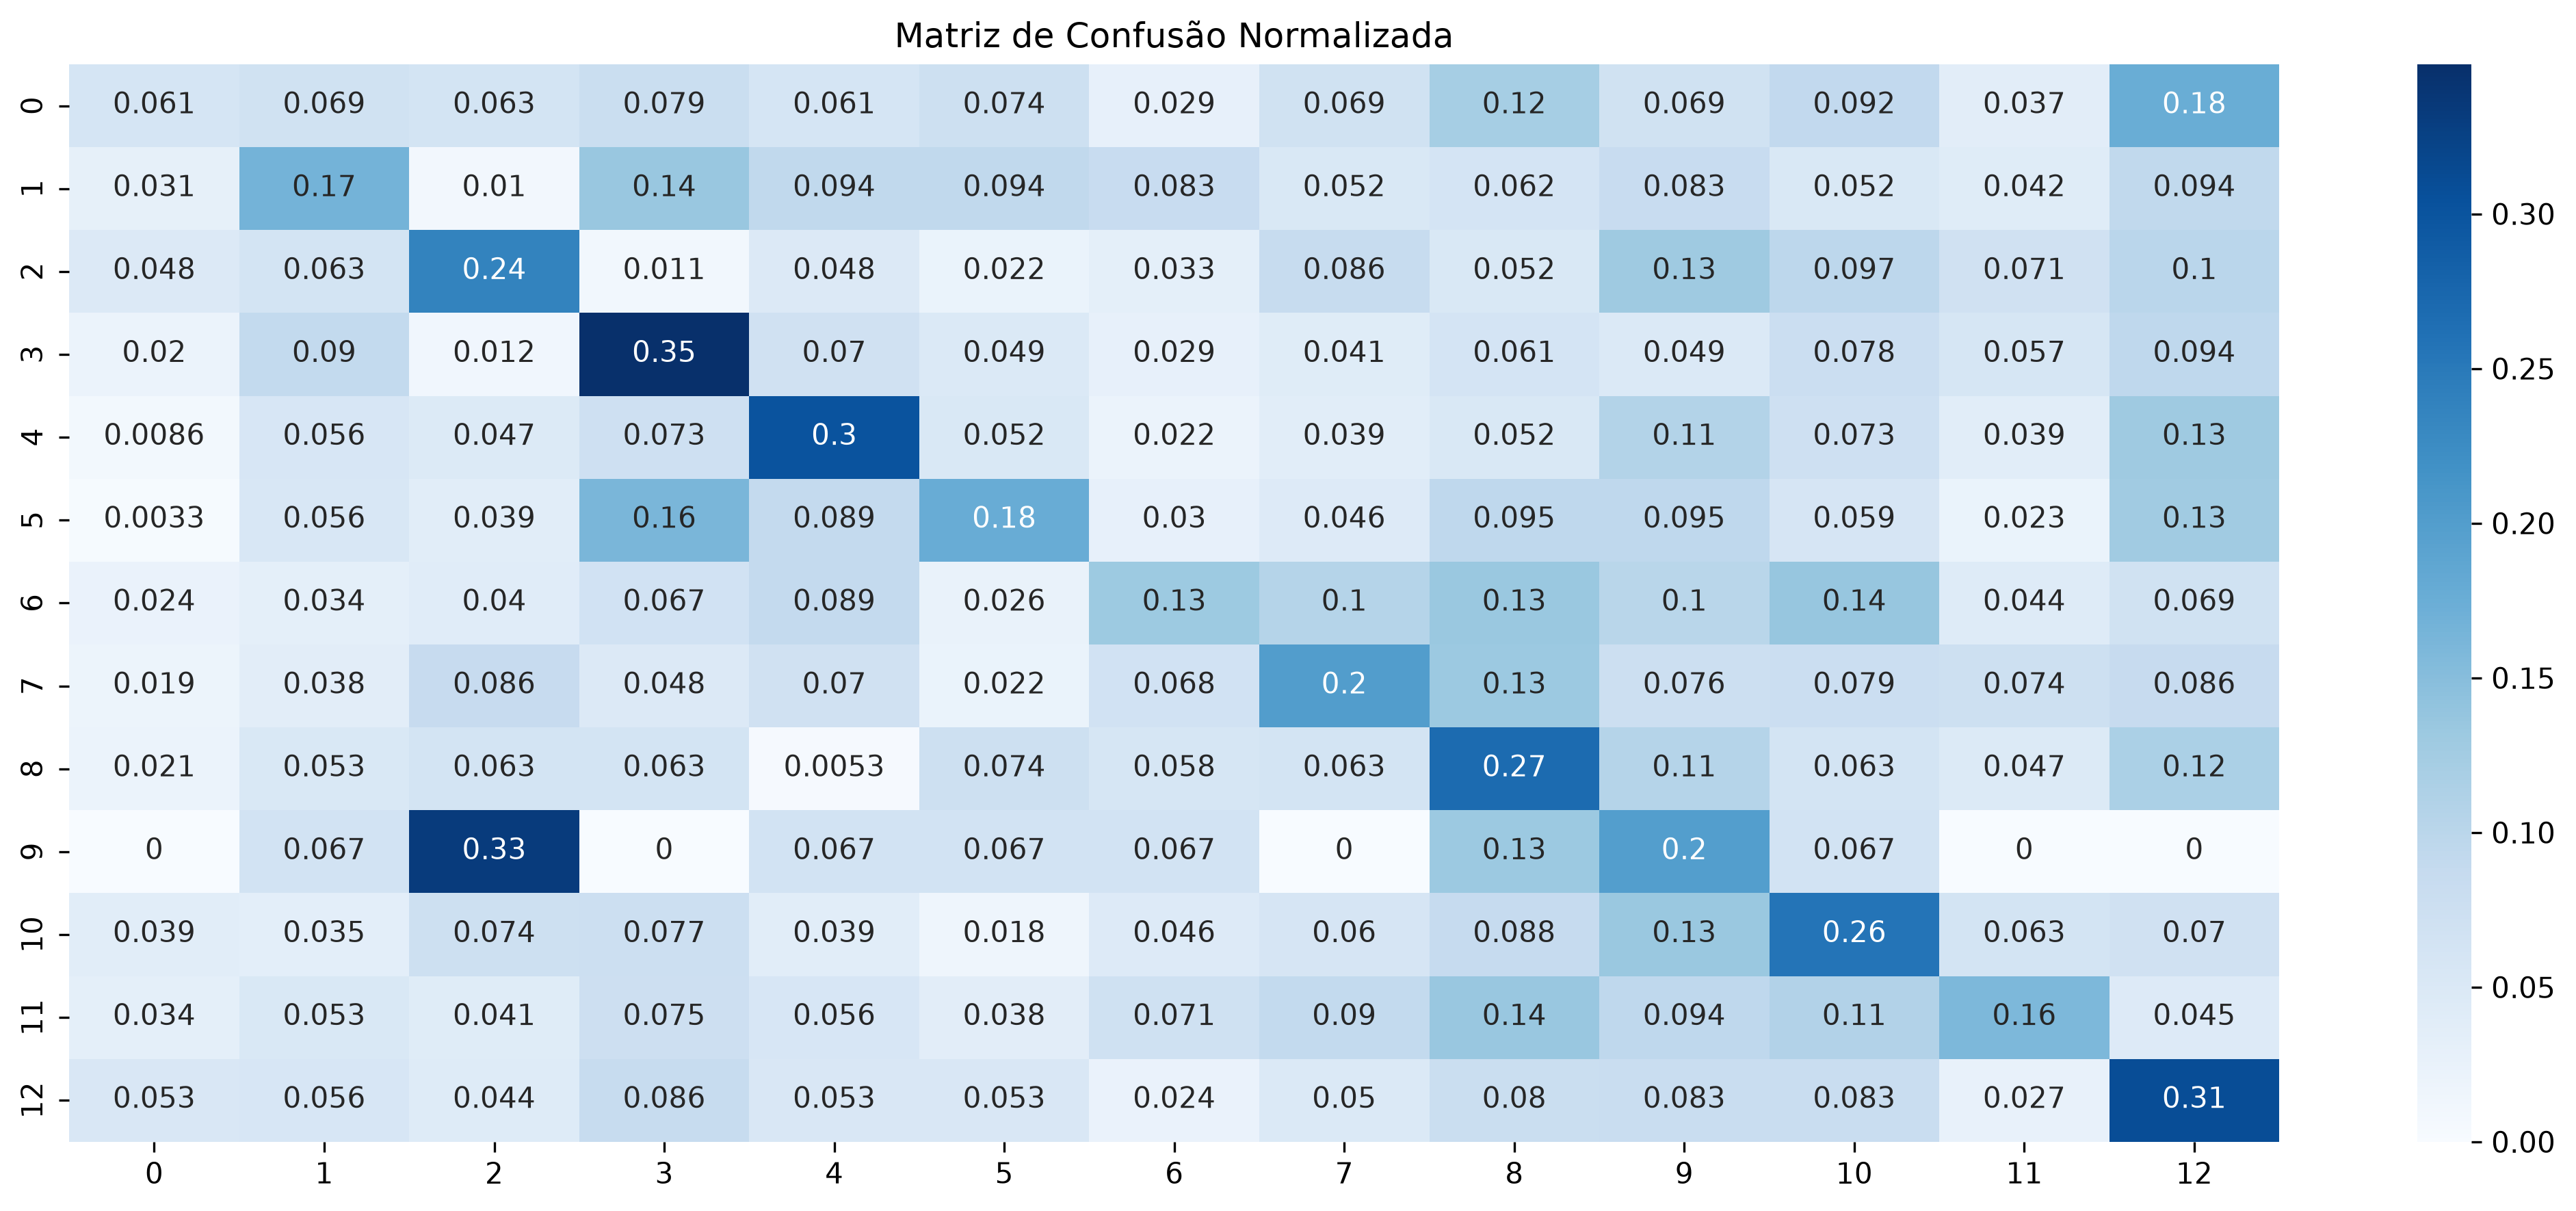

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

clf = LogisticRegression(max_iter=1_000, class_weight="balanced", C=1.0, n_jobs=-1)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("=" * 30 + "REPORT" + "=" * 30)

print(classification_report(y_test, y_pred, zero_division=0))

plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_test, y_pred, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

print("\n" * 10)

In [14]:
import copy
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

class SparseDataset(Dataset):
    def __init__(self, X_sparse, y_encoded):
        self.X_sparse = X_sparse.tocsr()
        self.y = torch.tensor(y_encoded, dtype=torch.long)

    def __len__(self):
        return self.X_sparse.shape[0]

    def __getitem__(self, idx):
        x_sample = self.X_sparse[idx].toarray().squeeze(0)

        return (
            torch.tensor(x_sample, dtype=torch.float32),
            self.y[idx]
        )

class SparseMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

le = LabelEncoder()
y_tr_enc = le.fit_transform(y_train)
y_te_enc = le.transform(y_test)

num_classes = len(le.classes_)

class_counts = np.bincount(y_tr_enc)
total_samples = len(y_tr_enc)
class_weights = total_samples / (num_classes * class_counts)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

def train_and_eval_mlp(
    X_tr,
    y_tr,
    X_te,
    y_te,
    name="MLP",
    epochs=20,
    batch_size=256,
    lr=0.001
):

    # =========================
    # Train / validation split
    # =========================

    idx_train, idx_val = train_test_split(
        np.arange(len(y_tr)),
        test_size=0.1,
        stratify=y_tr,
        random_state=42
    )

    full_train_dataset = SparseDataset(X_tr, y_tr)

    train_dataset = Subset(
        full_train_dataset,
        idx_train
    )

    val_dataset = Subset(
        full_train_dataset,
        idx_val
    )

    test_dataset = SparseDataset(X_te, y_te)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True if device.type == "cuda" else False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # =========================
    # Model
    # =========================

    model = SparseMLP(
        X_tr.shape[1],
        num_classes
    ).to(device)

    criterion = nn.CrossEntropyLoss(
        weight=weights_tensor
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    # =========================
    # Early stopping
    # =========================

    best_val_f1 = 0.0
    patience = 4
    patience_counter = 0

    best_model_weights = None

    print(
        f"\n==================== "
        f"Treinando {name} "
        f"===================="
    )

    for epoch in range(1, epochs + 1):

        # ---------------------
        # TRAIN
        # ---------------------

        model.train()

        running_loss = 0.0

        for inputs, targets in train_loader:

            inputs = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * inputs.size(0)
            )

        train_loss = (
            running_loss /
            len(train_dataset)
        )

        # ---------------------
        # VALIDATION
        # ---------------------

        model.eval()

        val_preds = []
        val_targets = []

        with torch.no_grad():

            for inputs, targets in val_loader:

                inputs = inputs.to(device)

                outputs = model(inputs)

                preds = (
                    torch.argmax(
                        outputs,
                        dim=1
                    )
                    .cpu()
                    .numpy()
                )

                val_preds.extend(preds)
                val_targets.extend(
                    targets.numpy()
                )

        val_f1 = f1_score(
            val_targets,
            val_preds,
            average="macro"
        )

        print(
            f"Epoch {epoch:02d}/{epochs:02d} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val F1 Macro: {val_f1:.4f}"
        )

        # ---------------------
        # EARLY STOPPING
        # ---------------------

        if val_f1 > best_val_f1:

            best_val_f1 = val_f1
            patience_counter = 0

            best_model_weights = copy.deepcopy(
                model.state_dict()
            )

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print(
                    f"Early stopping acionado "
                    f"na época {epoch}!"
                )

                break

    # Recupera melhor modelo
    model.load_state_dict(
        best_model_weights
    )

    # =========================
    # FINAL TEST
    # =========================

    model.eval()

    test_preds = []
    test_targets = []

    with torch.no_grad():

        for inputs, targets in test_loader:

            inputs = inputs.to(device)

            outputs = model(inputs)

            preds = (
                torch.argmax(
                    outputs,
                    dim=1
                )
                .cpu()
                .numpy()
            )

            test_preds.extend(preds)
            test_targets.extend(
                targets.numpy()
            )

    test_f1 = f1_score(
        test_targets,
        test_preds,
        average="macro"
    )

    print(
        f"\n{name} | "
        f"Best Val F1: {best_val_f1:.4f} | "
        f"Test F1 Macro: {test_f1:.4f}"
    )

    return (
        model,
        best_val_f1,
        test_f1,
        np.array(test_preds),
        np.array(test_targets)
    )

In [15]:
model_20, val_f1, test_f1, preds, targets = train_and_eval_mlp(
    X_train, y_tr_enc, X_test, y_te_enc, name="MLP"
)


==================== Treinando MLP ====================
Epoch 01/20 | Train Loss: 2.5617 | Val F1 Macro: 0.0836
Epoch 02/20 | Train Loss: 2.5013 | Val F1 Macro: 0.1931
Epoch 03/20 | Train Loss: 2.3142 | Val F1 Macro: 0.2911
Epoch 04/20 | Train Loss: 1.9818 | Val F1 Macro: 0.3435
Epoch 05/20 | Train Loss: 1.6285 | Val F1 Macro: 0.4094
Epoch 06/20 | Train Loss: 1.3071 | Val F1 Macro: 0.4724
Epoch 07/20 | Train Loss: 1.0711 | Val F1 Macro: 0.4975
Epoch 08/20 | Train Loss: 0.8529 | Val F1 Macro: 0.5321
Epoch 09/20 | Train Loss: 0.6790 | Val F1 Macro: 0.5534
Epoch 10/20 | Train Loss: 0.5635 | Val F1 Macro: 0.5505
Epoch 11/20 | Train Loss: 0.4938 | Val F1 Macro: 0.5614
Epoch 12/20 | Train Loss: 0.4023 | Val F1 Macro: 0.5566
Epoch 13/20 | Train Loss: 0.3536 | Val F1 Macro: 0.5345
Epoch 14/20 | Train Loss: 0.3066 | Val F1 Macro: 0.5733
Epoch 15/20 | Train Loss: 0.3282 | Val F1 Macro: 0.5534
Epoch 16/20 | Train Loss: 0.3225 | Val F1 Macro: 0.5709
Epoch 17/20 | Train Loss: 0.2322 | Val F1 Macro

In [20]:
print("\n==================== VEREDITO FINAL ====================")
print(f"F1 Macro: {val_f1:.4f}")

print("\nRelatório Detalhado por Membro (Melhor Modelo):")
print(classification_report(y_te_enc, preds, target_names=le.classes_))


==================== VEREDITO FINAL ====================
F1 Macro: 0.5733

Relatório Detalhado por Membro (Melhor Modelo):
                precision    recall  f1-score   support

         André       0.56      0.53      0.54       379
        Arthur       0.48      0.17      0.25        96
          Caio       0.61      0.64      0.63       269
          Cauã       0.75      0.75      0.75       244
         Guido       0.70      0.78      0.74       232
           Jão       0.60      0.63      0.62       305
          Luiz       0.62      0.60      0.61       505
       Luquete       0.60      0.72      0.66       825
     Peter Lee       0.43      0.43      0.43       190
Sr. Quick Açaí       0.10      0.07      0.08        15
          Você       0.66      0.63      0.64       284
         Yuras       0.66      0.66      0.66       266
         Ítalo       0.68      0.52      0.59       339

      accuracy                           0.62      3949
     macro avg       0.57      0.5

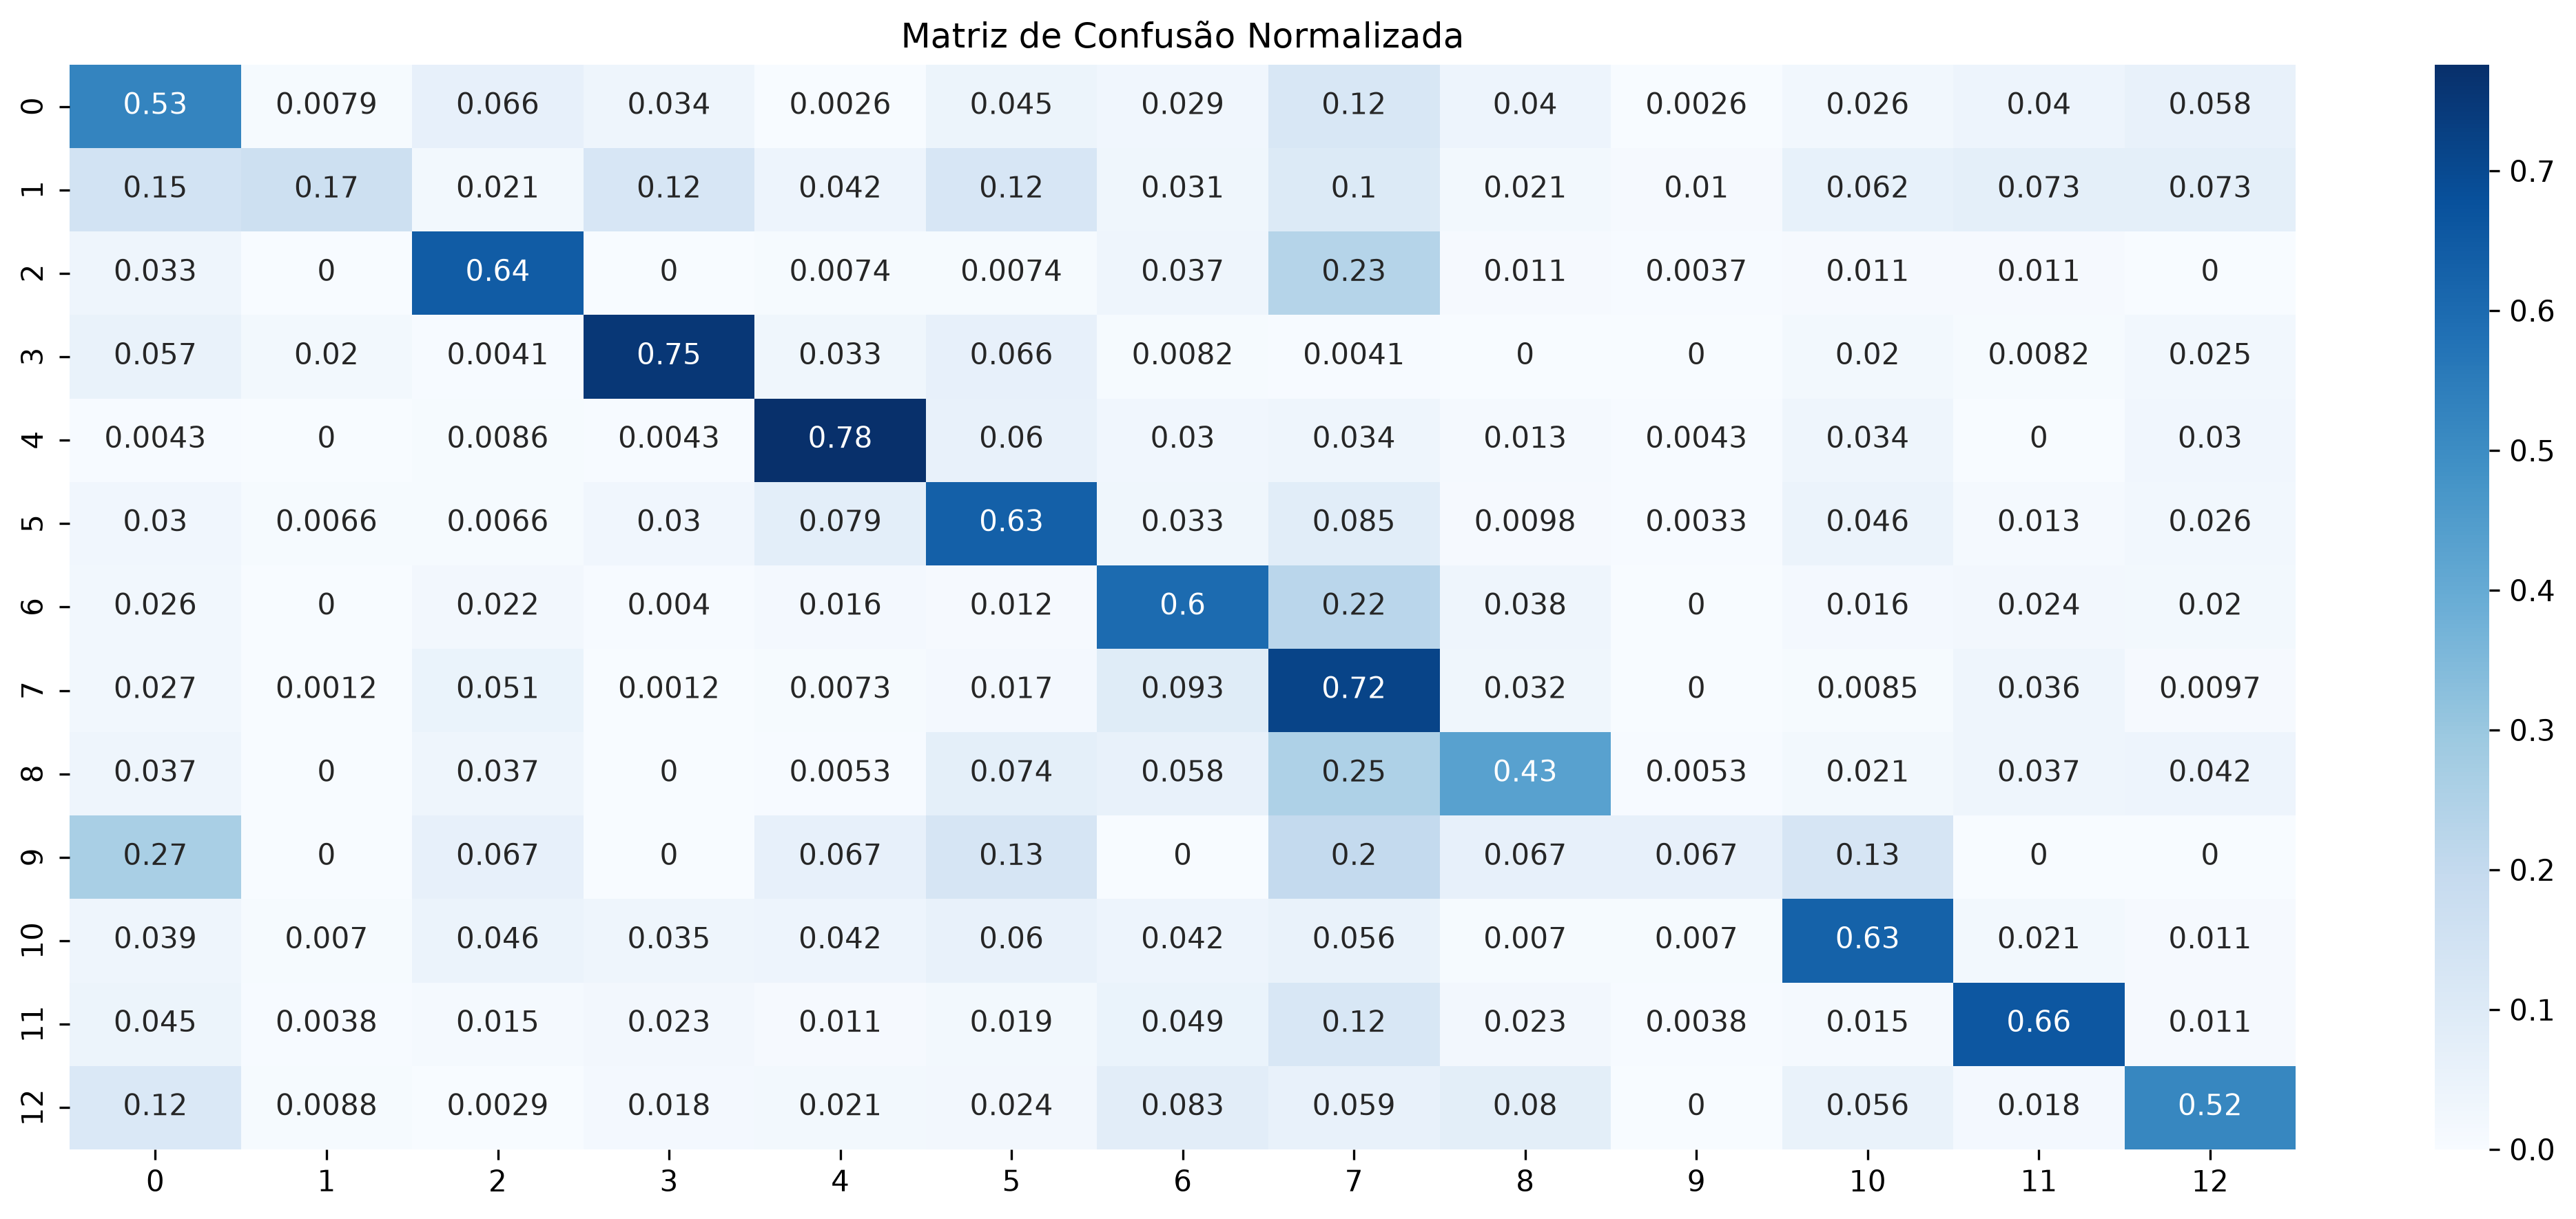

In [19]:
plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_te_enc, preds, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

In [25]:
import joblib

tfidf_vectorizer = joblib.load("../../artifacts/tfidf/tfidf_vectorizer.joblib")

In [29]:
# ============================================================
# 1. MODELO
# ============================================================

model_20.eval()
model_20.to("cpu")


# ============================================================
# 2. TAMANHO DOS BLOCOS
# ============================================================

n_temporais = (
    hora_inicio_sin_train.shape[1]
    + hora_inicio_cos_train.shape[1]
    + hora_fim_sin_train.shape[1]
    + hora_fim_cos_train.shape[1]
    + log_duracao_train.shape[1]
    + dia_inicio_dummies_array_train.shape[1]
    + dia_fim_dummies_array_train.shape[1]
)

n_comportamentais = (
    qtd_palavras_train.shape[1]
    + qtd_caracteres_train.shape[1]
    + caracter_por_palavra_train.shape[1]
)

n_cluster = cluster15_dummies_array_train.shape[1]

n_embeddings = embedding_train.shape[1]

n_tfidf = tfidf_train.shape[1]


print("Temporais:", n_temporais)
print("Comportamentais:", n_comportamentais)
print("Cluster:", n_cluster)
print("Embeddings:", n_embeddings)
print("TF-IDF:", n_tfidf)
print(
    "Total:",
    n_temporais
    + n_comportamentais
    + n_cluster
    + n_embeddings
    + n_tfidf
)

Temporais: 17
Comportamentais: 3
Cluster: 14
Embeddings: 384
TF-IDF: 100000
Total: 100418


In [30]:
inicio = 0

idx_temporais = np.arange(
    inicio,
    inicio + n_temporais
)

inicio += n_temporais

idx_comportamentais = np.arange(
    inicio,
    inicio + n_comportamentais
)

inicio += n_comportamentais

idx_cluster = np.arange(
    inicio,
    inicio + n_cluster
)

inicio += n_cluster

idx_embeddings = np.arange(
    inicio,
    inicio + n_embeddings
)

inicio += n_embeddings

idx_tfidf = np.arange(
    inicio,
    inicio + n_tfidf
)


blocos = {
    "Temporais": idx_temporais,
    "Comportamentais": idx_comportamentais,
    "Cluster 15": idx_cluster,
    "Embeddings": idx_embeddings,
    "TF-IDF": idx_tfidf,
}

In [31]:
N_BACKGROUND = 30

X_background = X_train[:N_BACKGROUND].toarray().astype(np.float32)

background = X_background.mean(axis=0)

N_EXPLICACAO = 50

X_explicacao = X_test[:N_EXPLICACAO].toarray().astype(np.float32)

In [32]:
def montar_coalicoes(mascara, x_real):
    
    mascara = np.asarray(mascara)

    X = np.tile(
        background,
        (len(mascara), 1)
    )

    for j, (_, indices) in enumerate(blocos.items()):

        linhas_ativas = mascara[:, j] == 1

        if np.any(linhas_ativas):
            X[np.ix_(linhas_ativas, indices)] = x_real[indices]

    return X

In [33]:
def criar_predictor(x_real):

    def predictor(mascara):

        X = montar_coalicoes(
            mascara,
            x_real
        )

        X_tensor = torch.tensor(
            X,
            dtype=torch.float32
        )

        with torch.no_grad():

            logits = model_20(X_tensor)

            probabilidades = torch.softmax(
                logits,
                dim=1
            )

        return probabilidades.numpy()

    return predictor

In [34]:
import shap

feature_names_blocos = [
    "Temporais",
    "Comportamentais",
    "Cluster 15",
    "Embeddings",
    "TF-IDF"
]

shap_por_amostra = []

for i in range(N_EXPLICACAO):

    print(
        f"Explicando {i + 1}/{N_EXPLICACAO}"
    )

    predictor = criar_predictor(
        X_explicacao[i]
    )

    explainer = shap.KernelExplainer(
        predictor,
        np.zeros((1, 5))
    )

    valores = explainer.shap_values(
        np.ones((1, 5)),
        nsamples=64
    )

    shap_por_amostra.append(valores)

Explicando 1/50


100%|██████████| 1/1 [00:00<00:00,  8.71it/s]


Explicando 2/50


100%|██████████| 1/1 [00:00<00:00, 17.37it/s]


Explicando 3/50


...

100%|██████████| 1/1 [00:00<00:00, 18.23it/s]


Explicando 49/50


100%|██████████| 1/1 [00:00<00:00, 17.90it/s]


Explicando 50/50


100%|██████████| 1/1 [00:00<00:00, 18.03it/s]


In [36]:
# Compatibilidade com diferentes versões do SHAP

if isinstance(shap_por_amostra[0], list):

    valores_abs = np.stack([
        np.abs(np.asarray(v))
        for v in shap_por_amostra
    ])

else:

    valores_abs = np.stack([
        np.abs(np.asarray(v))
        for v in shap_por_amostra
    ])


shap_array = np.squeeze(
    np.asarray(shap_por_amostra)
)

print(shap_array.shape)

(50, 5, 13)


In [37]:
# Importância absoluta média
importancia_blocos = np.mean(
    np.abs(shap_array),
    axis=(0, 2)
)

for nome, importancia in sorted(
    zip(feature_names_blocos, importancia_blocos),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{nome:20s} {importancia:.6f}")

TF-IDF               0.095719
Embeddings           0.022629
Temporais            0.016215
Comportamentais      0.013995
Cluster 15           0.007457


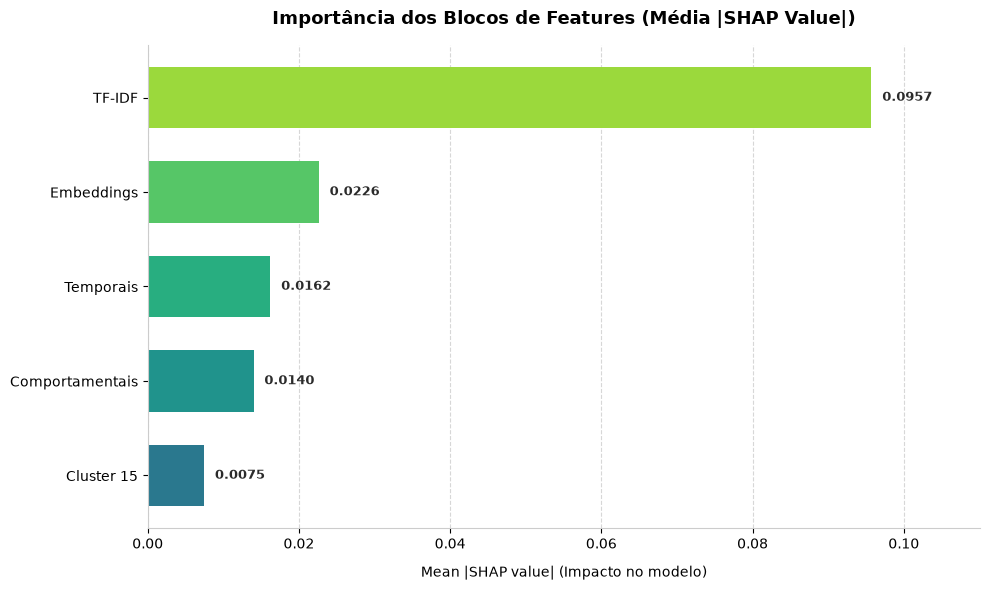

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Reordenar os dados
ordem = np.argsort(importancia_blocos)
nomes_ordenados = np.array(feature_names_blocos)[ordem]
valores_ordenados = importancia_blocos[ordem]

plt.figure(figsize=(10, 6))

# Criar um gradiente de cores (corrigido para 'viridis' em minúsculo)
cmap = plt.get_cmap("viridis")
cores = cmap(np.linspace(0.4, 0.85, len(valores_ordenados)))

# Plot das barras horizontais
bars = plt.barh(
    nomes_ordenados,
    valores_ordenados,
    color=cores,
    edgecolor="none",
    height=0.65,
)

# Adicionar os valores numéricos ao lado/final de cada barra
max_val = np.max(valores_ordenados)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
        color="#2b2b2b",
    )

# Formatação e Estilo
plt.title(
    "Importância dos Blocos de Features (Média |SHAP Value|)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Mean |SHAP value| (Impacto no modelo)", fontsize=10, labelpad=10)

# Remover bordas desnecessárias (spines)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# Grade suave apenas no eixo X
plt.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

# Expandir o limite do eixo X para caberem os rótulos sem cortar
plt.xlim(0, max_val * 1.15)

plt.tight_layout()
plt.show()

Agora, vamos tentar a ablação: Sem os Clusters

In [41]:
X_train_no_clusters = sp.hstack([
    hora_inicio_sin_train,
    hora_inicio_cos_train,
    hora_fim_sin_train,
    hora_fim_cos_train,
    log_duracao_train,
    dia_inicio_dummies_array_train,
    dia_fim_dummies_array_train,
    qtd_palavras_train,
    qtd_caracteres_train,
    caracter_por_palavra_train,
    embedding_train,
    tfidf_train
]).tocsr()

X_test_no_clusters = sp.hstack([
    hora_inicio_sin_test,
    hora_inicio_cos_test,
    hora_fim_sin_test,
    hora_fim_cos_test,
    log_duracao_test,
    dia_inicio_dummies_array_test,
    dia_fim_dummies_array_test,
    qtd_palavras_test,
    qtd_caracteres_test,
    caracter_por_palavra_test,
    embedding_test,
    tfidf_test
]).tocsr()

In [42]:
model_no_clusters, val_f1_no_clusters, test_f1_no_clusters, preds_no_clusters, targets_no_clusters = train_and_eval_mlp(
    X_train_no_clusters, y_tr_enc, X_test_no_clusters, y_te_enc, name="MLP (No Clusters)"
)


==================== Treinando MLP (No Clusters) ====================
Epoch 01/20 | Train Loss: 2.5643 | Val F1 Macro: 0.0433
Epoch 02/20 | Train Loss: 2.5137 | Val F1 Macro: 0.1650
Epoch 03/20 | Train Loss: 2.3180 | Val F1 Macro: 0.2765
Epoch 04/20 | Train Loss: 1.9772 | Val F1 Macro: 0.3277
Epoch 05/20 | Train Loss: 1.6260 | Val F1 Macro: 0.3858
Epoch 06/20 | Train Loss: 1.2745 | Val F1 Macro: 0.4868
Epoch 07/20 | Train Loss: 1.0121 | Val F1 Macro: 0.5516
Epoch 08/20 | Train Loss: 0.7915 | Val F1 Macro: 0.5756
Epoch 09/20 | Train Loss: 0.6549 | Val F1 Macro: 0.5813
Epoch 10/20 | Train Loss: 0.4822 | Val F1 Macro: 0.5877
Epoch 11/20 | Train Loss: 0.4108 | Val F1 Macro: 0.5851
Epoch 12/20 | Train Loss: 0.3380 | Val F1 Macro: 0.5892
Epoch 13/20 | Train Loss: 0.3123 | Val F1 Macro: 0.5860
Epoch 14/20 | Train Loss: 0.2579 | Val F1 Macro: 0.6055
Epoch 15/20 | Train Loss: 0.2449 | Val F1 Macro: 0.6047
Epoch 16/20 | Train Loss: 0.2155 | Val F1 Macro: 0.5977
Epoch 17/20 | Train Loss: 0.1877 

In [43]:
print("\n==================== VEREDITO FINAL ====================")
print(f"F1 Macro: {val_f1_no_clusters:.4f}")

print("\nRelatório Detalhado por Membro (Modelo No Clusters):")
print(classification_report(y_te_enc, preds_no_clusters, target_names=le.classes_))


==================== VEREDITO FINAL ====================
F1 Macro: 0.6055

Relatório Detalhado por Membro (Modelo No Clusters):
                precision    recall  f1-score   support

         André       0.49      0.63      0.55       379
        Arthur       0.35      0.23      0.28        96
          Caio       0.55      0.68      0.61       269
          Cauã       0.76      0.75      0.75       244
         Guido       0.78      0.72      0.75       232
           Jão       0.65      0.60      0.63       305
          Luiz       0.69      0.66      0.67       505
       Luquete       0.68      0.73      0.71       825
     Peter Lee       0.49      0.35      0.41       190
Sr. Quick Açaí       0.08      0.07      0.07        15
          Você       0.62      0.68      0.65       284
         Yuras       0.78      0.59      0.67       266
         Ítalo       0.70      0.62      0.66       339

      accuracy                           0.64      3949
     macro avg       0.59    

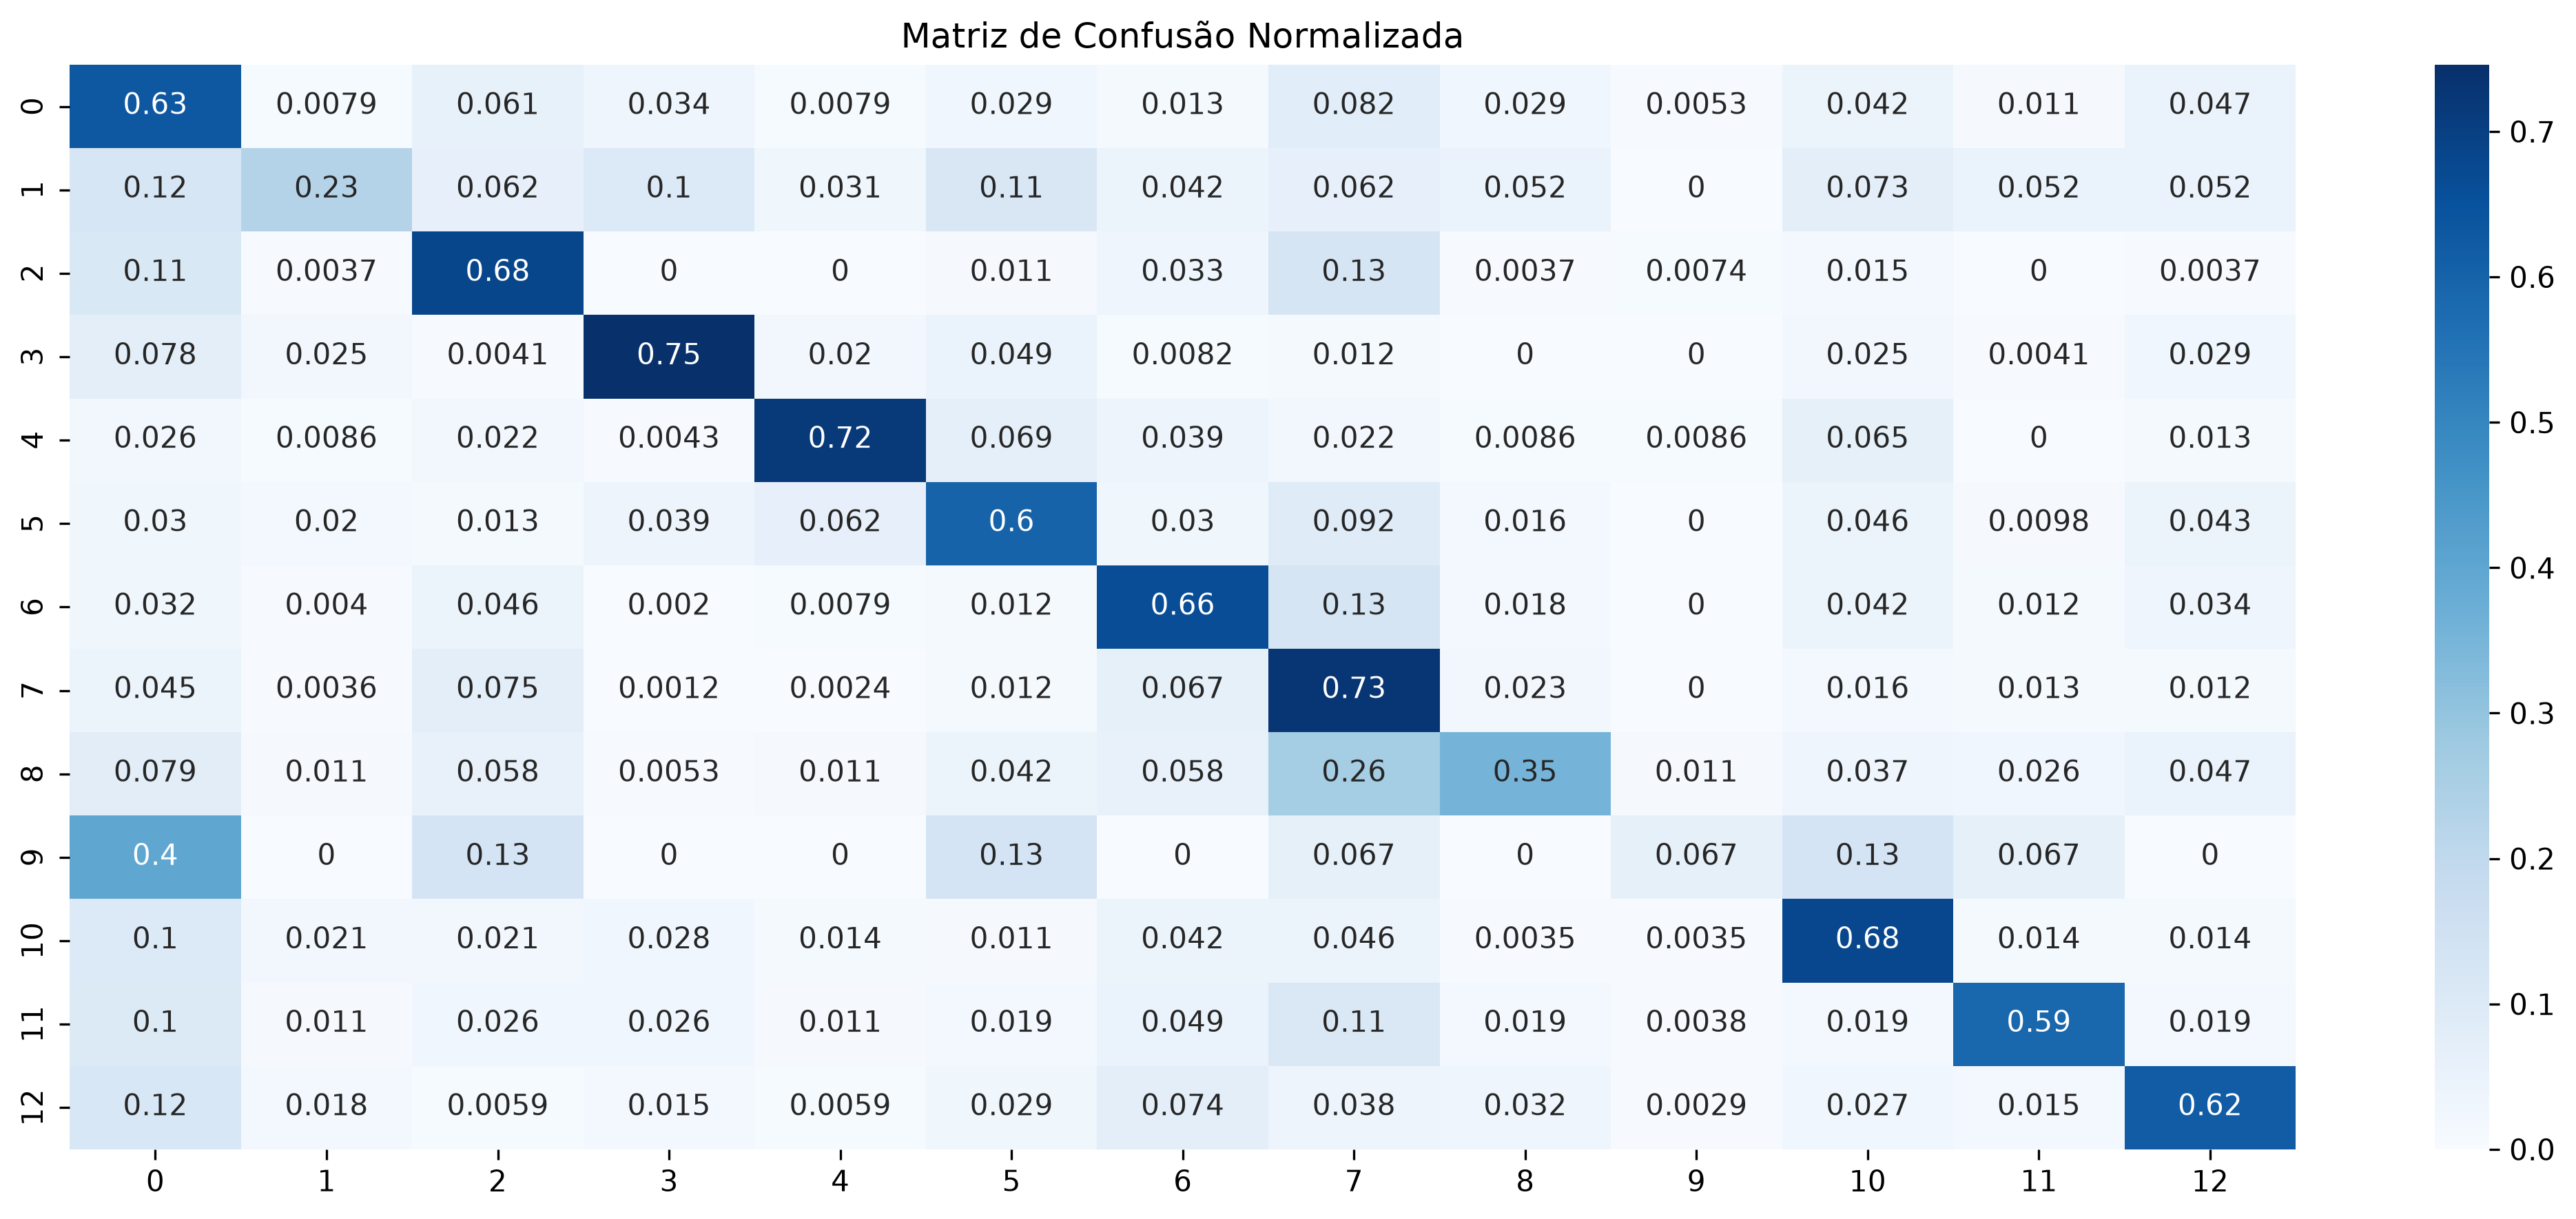

In [44]:
plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_te_enc, preds_no_clusters, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

In [46]:
n_temporais = (
    hora_inicio_sin_train.shape[1]
    + hora_inicio_cos_train.shape[1]
    + hora_fim_sin_train.shape[1]
    + hora_fim_cos_train.shape[1]
    + log_duracao_train.shape[1]
    + dia_inicio_dummies_array_train.shape[1]
    + dia_fim_dummies_array_train.shape[1]
)

n_comportamentais = (
    qtd_palavras_train.shape[1]
    + qtd_caracteres_train.shape[1]
    + caracter_por_palavra_train.shape[1]
)

n_embeddings = embedding_train.shape[1]
n_tfidf = tfidf_train.shape[1]

print(n_temporais, n_comportamentais, n_embeddings, n_tfidf)
print("Total:", n_temporais + n_comportamentais + n_embeddings + n_tfidf)
print("X_train_no_clusters:", X_train_no_clusters.shape[1])

17 3 384 100000
Total: 100404
X_train_no_clusters: 100404


In [47]:
idx_temporais = np.arange(0, 17)

idx_comportamentais = np.arange(17, 20)

idx_embeddings = np.arange(20, 20 + 384)

idx_tfidf = np.arange(20 + 384, 100404)

print(
    len(idx_temporais),
    len(idx_comportamentais),
    len(idx_embeddings),
    len(idx_tfidf)
)

17 3 384 100000


In [56]:
X_train_sample = X_train_no_clusters[:100].toarray()
X_test_sample = X_test_no_clusters[:50].toarray()

X_test_sample = X_test_no_clusters[:50].toarray()

model_no_clusters.eval()
model_no_clusters.to("cpu")


def predictor(mascaras):
    resultados = []

    for mascara in mascaras:

        X = X_test_sample.copy()

        if mascara[0] == 0:
            X[:, idx_temporais] = 0

        if mascara[1] == 0:
            X[:, idx_comportamentais] = 0

        if mascara[2] == 0:
            X[:, idx_embeddings] = 0

        if mascara[3] == 0:
            X[:, idx_tfidf] = 0

        with torch.no_grad():
            X_tensor = torch.tensor(
                X,
                dtype=torch.float32
            )

            logits = model_no_clusters(X_tensor)
            probs = torch.softmax(logits, dim=1).numpy()

        resultados.append(probs.mean(axis=0))

    return np.asarray(resultados)


explainer = shap.KernelExplainer(
    predictor,
    np.zeros((1, 4))
)

shap_por_amostra = explainer.shap_values(
    np.ones((1, 4)),
    nsamples="auto"
)

print(np.asarray(shap_por_amostra).shape)

100%|██████████| 1/1 [00:00<00:00,  1.31it/s]

(1, 4, 13)


In [58]:
shap_array = np.squeeze(np.asarray(shap_por_amostra))

print(shap_array.shape)

(4, 13)


In [59]:
feature_names_blocos = [
    "Temporais",
    "Comportamentais",
    "Embeddings",
    "TF-IDF"
]

importancia_blocos = np.mean(
    np.abs(shap_array),
    axis=1
)

for nome, importancia in sorted(
    zip(feature_names_blocos, importancia_blocos),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{nome:20s} {importancia:.6f}")

TF-IDF               0.088590
Comportamentais      0.030382
Temporais            0.016543
Embeddings           0.013798


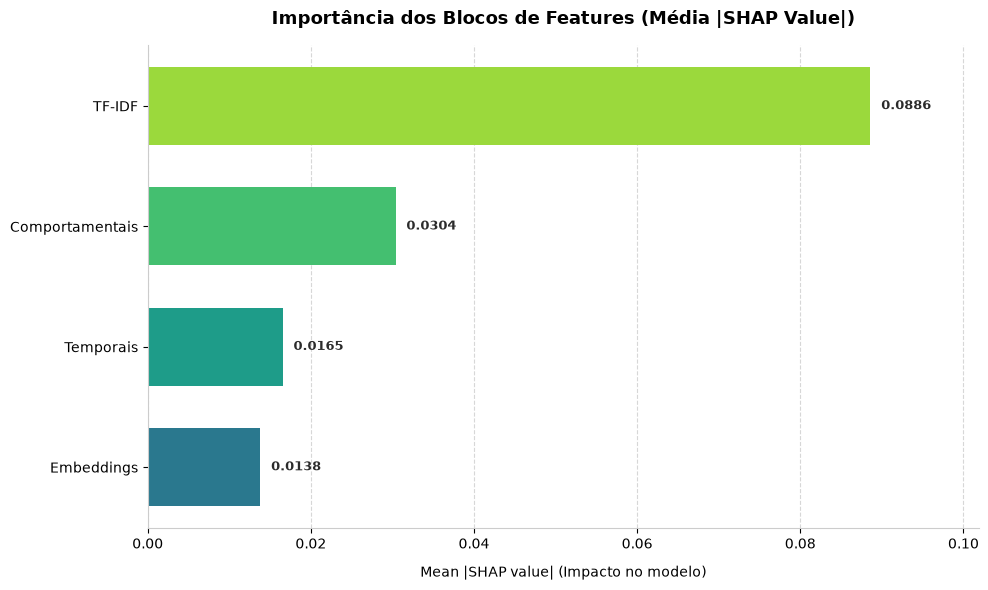

In [60]:
ordem = np.argsort(importancia_blocos)
nomes_ordenados = np.array(feature_names_blocos)[ordem]
valores_ordenados = importancia_blocos[ordem]

plt.figure(figsize=(10, 6))

# Criar um gradiente de cores (corrigido para 'viridis' em minúsculo)
cmap = plt.get_cmap("viridis")
cores = cmap(np.linspace(0.4, 0.85, len(valores_ordenados)))

# Plot das barras horizontais
bars = plt.barh(
    nomes_ordenados,
    valores_ordenados,
    color=cores,
    edgecolor="none",
    height=0.65,
)

# Adicionar os valores numéricos ao lado/final de cada barra
max_val = np.max(valores_ordenados)
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + (max_val * 0.015),
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold",
        color="#2b2b2b",
    )

# Formatação e Estilo
plt.title(
    "Importância dos Blocos de Features (Média |SHAP Value|)",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Mean |SHAP value| (Impacto no modelo)", fontsize=10, labelpad=10)

# Remover bordas desnecessárias (spines)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

# Grade suave apenas no eixo X
plt.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

# Expandir o limite do eixo X para caberem os rótulos sem cortar
plt.xlim(0, max_val * 1.15)

plt.tight_layout()
plt.show()

Próxima ablação: Sem Embeddings

In [62]:
X_train_no_embeddings = sp.hstack([
    hora_inicio_sin_train,
    hora_inicio_cos_train,
    hora_fim_sin_train,
    hora_fim_cos_train,
    log_duracao_train,
    dia_inicio_dummies_array_train,
    dia_fim_dummies_array_train,
    qtd_palavras_train,
    qtd_caracteres_train,
    caracter_por_palavra_train,
    tfidf_train
]).tocsr()

X_test_no_embeddings = sp.hstack([
    hora_inicio_sin_test,
    hora_inicio_cos_test,
    hora_fim_sin_test,
    hora_fim_cos_test,
    log_duracao_test,
    dia_inicio_dummies_array_test,
    dia_fim_dummies_array_test,
    qtd_palavras_test,
    qtd_caracteres_test,
    caracter_por_palavra_test,
    tfidf_test
]).tocsr()

In [63]:
model_no_embeddings, val_f1_no_embeddings, test_f1_no_embeddings, preds_no_embeddings, targets_no_embeddings = train_and_eval_mlp(
    X_train_no_embeddings, y_tr_enc, X_test_no_embeddings, y_te_enc, name="MLP (No Clusters + Embeddings)"
)


==================== Treinando MLP (No Clusters + Embeddings) ====================
Epoch 01/20 | Train Loss: 2.5678 | Val F1 Macro: 0.0178
Epoch 02/20 | Train Loss: 2.5430 | Val F1 Macro: 0.1643
Epoch 03/20 | Train Loss: 2.4560 | Val F1 Macro: 0.2123
Epoch 04/20 | Train Loss: 2.1905 | Val F1 Macro: 0.2967
Epoch 05/20 | Train Loss: 1.8257 | Val F1 Macro: 0.3826
Epoch 06/20 | Train Loss: 1.5094 | Val F1 Macro: 0.4543
Epoch 07/20 | Train Loss: 1.2593 | Val F1 Macro: 0.4449
Epoch 08/20 | Train Loss: 1.0515 | Val F1 Macro: 0.5353
Epoch 09/20 | Train Loss: 0.8699 | Val F1 Macro: 0.5360
Epoch 10/20 | Train Loss: 0.7370 | Val F1 Macro: 0.5619
Epoch 11/20 | Train Loss: 0.6249 | Val F1 Macro: 0.5670
Epoch 12/20 | Train Loss: 0.5294 | Val F1 Macro: 0.5852
Epoch 13/20 | Train Loss: 0.4566 | Val F1 Macro: 0.5707
Epoch 14/20 | Train Loss: 0.4076 | Val F1 Macro: 0.5639
Epoch 15/20 | Train Loss: 0.3857 | Val F1 Macro: 0.5748
Epoch 16/20 | Train Loss: 0.3558 | Val F1 Macro: 0.5677
Early stopping acion

In [66]:
print("\n==================== VEREDITO FINAL ====================")
print(f"F1 Macro: {val_f1_no_embeddings:.4f}")

print("\nRelatório Detalhado por Membro (Modelo No Clusters + Embeddings):")
print(classification_report(y_te_enc, preds_no_embeddings, target_names=le.classes_))


==================== VEREDITO FINAL ====================
F1 Macro: 0.5852

Relatório Detalhado por Membro (Modelo No Clusters + Embeddings):
                precision    recall  f1-score   support

         André       0.63      0.47      0.53       379
        Arthur       0.29      0.33      0.31        96
          Caio       0.72      0.53      0.61       269
          Cauã       0.82      0.69      0.75       244
         Guido       0.68      0.68      0.68       232
           Jão       0.54      0.58      0.56       305
          Luiz       0.52      0.65      0.57       505
       Luquete       0.66      0.63      0.65       825
     Peter Lee       0.31      0.57      0.40       190
Sr. Quick Açaí       0.09      0.07      0.08        15
          Você       0.69      0.57      0.62       284
         Yuras       0.64      0.61      0.62       266
         Ítalo       0.63      0.62      0.62       339

      accuracy                           0.59      3949
     macro avg  

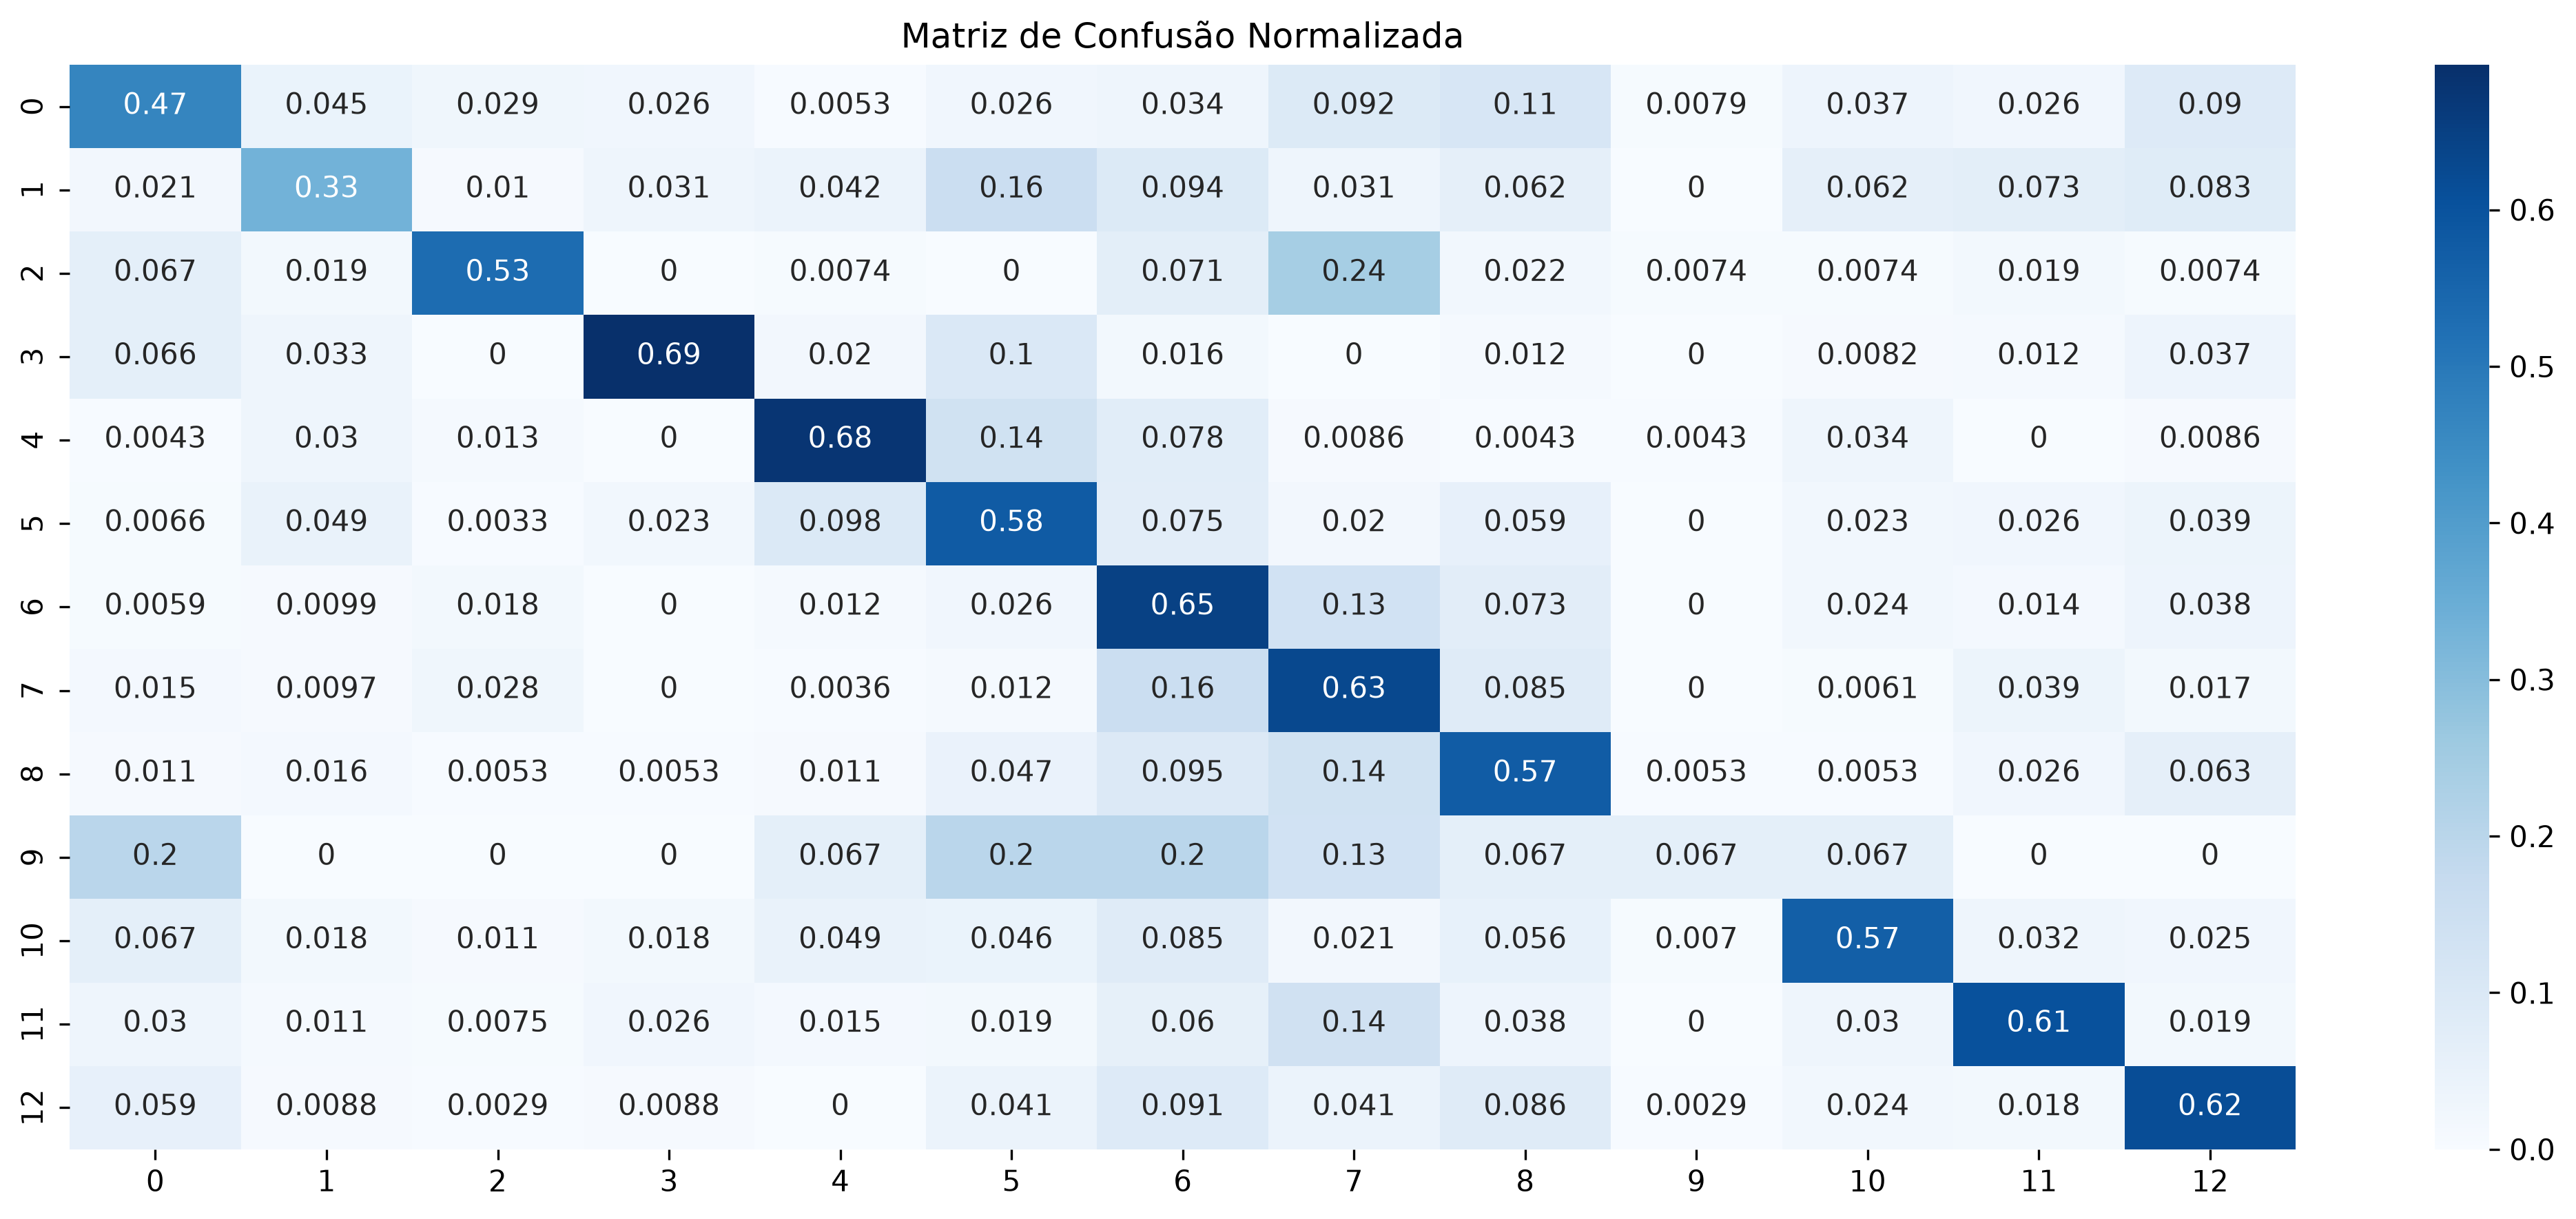

In [65]:
plt.figure(figsize=(14, 6), dpi=300)

sns.heatmap(confusion_matrix(y_te_enc, preds_no_embeddings, normalize="true"), annot=True, cmap="Blues")

plt.title("Matriz de Confusão Normalizada")
plt.tight_layout()

| Versão | Representação                                   | Macro F1 (teste) |
| ------ | ----------------------------------------------- | ---------------: |
| V1     | TF-IDF                                          |           0,2956 |
| V1     | TF-IDF + Embedding                              |           0,2963 |
| V1     | TF-IDF + Cluster (K=25)                         |           0,2991 |
| V1     | TF-IDF + Embedding + Cluster (K=25)             |       **0,3016** |
| V2     | TF-IDF + Embedding + Cluster (K=15)             |           0,5533 |
| V2     | TF-IDF + Embedding, **sem Cluster**             |       **0,5691** |
| V2     | TF-IDF + Embedding, sem Cluster e sem Embedding |           0,5394 |


## Resultados

Na V1, a inclusão das representações de embedding e clustering apresentou ganhos incrementais. O modelo utilizando conjuntamente TF-IDF, embeddings e clusters com \(K=25\) obteve o maior Macro F1 entre as configurações avaliadas, com 0,3016, superando o modelo baseado apenas em TF-IDF, que apresentou Macro F1 de 0,2956. Embora os ganhos individuais tenham sido pequenos, a combinação das representações apresentou o melhor desempenho da V1 e foi utilizada como configuração final.

Na V2, a utilização de grupos de cinco mensagens por membro, juntamente com novas características temporais e comportamentais, produziu um aumento substancial no desempenho. A configuração inicial, utilizando TF-IDF, embeddings e clustering com \(K=15\), alcançou Macro F1 de 0,5533 no conjunto de teste.

A análise de importância dos blocos de features e a posterior ablação do clustering indicaram que o cluster apresentava baixa contribuição preditiva. Após sua remoção, o modelo apresentou Macro F1 de 0,5691 e accuracy de 64%, representando uma melhora em relação à configuração com clustering. Portanto, o clustering foi removido da configuração final da V2, embora sua utilização permaneça relevante para a análise exploratória dos padrões de mensagens.

Por outro lado, a ablação dos embeddings resultou em uma redução do Macro F1 para 0,5394, indicando que, apesar de sua importância relativa ser inferior à do TF-IDF, a representação semântica ainda fornece informação preditiva relevante quando combinada às demais características.

Assim, a configuração selecionada para a V2 é composta por TF-IDF + embeddings + características temporais e comportamentais, sem utilização do clustering como feature do modelo. Essa configuração alcançou Macro F1 de 0,5691, quase duplicando o desempenho obtido pela V1 (0,3016).

In [70]:
import joblib

torch.save(
    model_no_clusters.state_dict(),
    "../../artifacts/models/scia_mlp_no_clusters.pt"
)

joblib.dump(
    le,
    "../../artifacts/models/label_encoder.joblib"
)

['../../artifacts/models/label_encoder.joblib']

In [69]:
sparse.save_npz(
    "../../artifacts/analysis/X_test_no_clusters.npz",
    X_test_no_clusters
)

np.save(
    "../../artifacts/analysis/y_test.npy",
    y_te_enc
)